In [1]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import TextVectorization, Input, Dense, Embedding
from tensorflow.keras.layers import GlobalMaxPooling1D, Conv1D, MaxPooling1D
from tensorflow.keras.models import Model

In [3]:
# Unfortunately this URL doesn't work directly with pd.read_csv
!wget -nc https://lazyprogrammer.me/course_files/spam.csv

--2026-05-02 10:59:22--  https://lazyprogrammer.me/course_files/spam.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3030::ac43:d5a6, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [text/csv]
Saving to: ‘spam.csv’

spam.csv            100%[===================>] 491.86K  --.-KB/s    in 0.04s   

2026-05-02 10:59:22 (13.3 MB/s) - ‘spam.csv’ saved [503663/503663]



In [4]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# drop unnecessary columns
df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
# rename columns to something better
df.columns = ['labels', 'data']
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
# create binary labels
df['b_labels'] = df['labels'].map({'ham': 0, 'spam': 1})
Y = df['b_labels'].values
# split up the data
df_train, df_test, Ytrain, Ytest = train_test_split(
    df['data'], Y, test_size=0.33)
# create tf datasets
train_ds = tf.data.Dataset.from_tensor_slices((df_train.values, Ytrain))
test_ds = tf.data.Dataset.from_tensor_slices((df_test.values, Ytest))
# Convert sentences to sequences
MAX_VOCAB_SIZE = 20000
vectorization = TextVectorization(max_tokens=MAX_VOCAB_SIZE, output_sequence_length=T)
vectorization.adapt(train_ds.map(lambda x, y: x))
# Shuffle and batch the dataset
train_ds = train_ds.shuffle(
    buffer_size=10000).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)
V = len(vectorization.get_vocabulary())

In [16]:
# This is annoying, but we have to find the max sequence length first
# and pad ALL sequences to this length
# Otherwise, with some inputs, the resulting array will be too short in the time
# dimension, leading to a series of convolutions shrinking the input length to 0
T = 0
for x, y in train_ds:
  t = vectorization(x).shape[1]
  if t > T:
    T = t
print(T)

107


In [17]:
# Create the model

# We get to choose embedding dimensionality
D = 20

# Note: we actually want to the size of the embedding to (V + 1) x D,
# because the first index starts from 1 and not 0.
# Thus, if the final index of the embedding matrix is V,
# then it actually must have size V + 1.

# if string not specified, will get string -> float casting error
i = Input(shape=(1,), dtype=tf.string)
x = vectorization(i)
x = Embedding(V, D)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)

In [18]:
# Compile and fit
model.compile(
  loss='binary_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)


print('Training model...')
r = model.fit(
  train_ds,
  epochs=5,
  validation_data=test_ds
)

Training model...
Epoch 1/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8645 - loss: 0.3875 - val_accuracy: 0.8624 - val_loss: 0.2605
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9574 - loss: 0.1130 - val_accuracy: 0.9793 - val_loss: 0.0682
Epoch 3/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9917 - loss: 0.0236 - val_accuracy: 0.9864 - val_loss: 0.0544
Epoch 4/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9987 - loss: 0.0055 - val_accuracy: 0.9875 - val_loss: 0.0462
Epoch 5/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9992 - loss: 0.0026 - val_accuracy: 0.9875 - val_loss: 0.0502


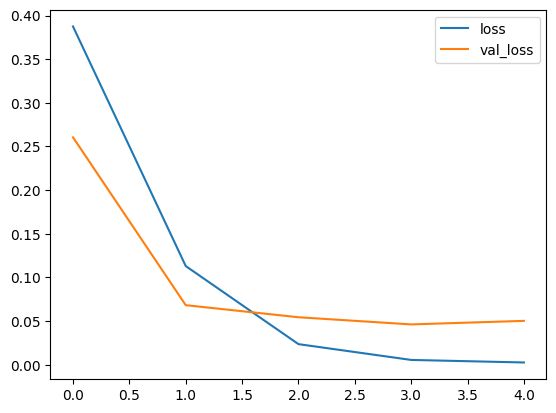

In [19]:
# Plot loss per iteration
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

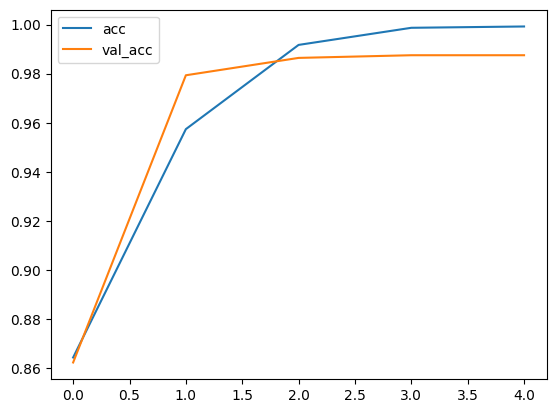

In [20]:
# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [21]:
from sklearn.metrics import f1_score
f1_score(Ytrain, model.predict(df_train.values) > 0.5)

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


0.9989888776541962

In [22]:
f1_score(Ytest, model.predict(df_test.values) > 0.5)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


0.9533468559837728